<a href="https://colab.research.google.com/github/Lohitasrith01/Abstractive-Text-Summarization-with-BART/blob/main/Text_Summerization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Summarization using LLMs
In this part, we will use a pre-trained large language model (LLM) to perform abstractive summarization. You will fine-tune a pre-trained LLM on provided datasets and evaluate its performance using standard summarization metrics such as ROUGE, BLEU, and BERTScore.
The model for this task is `facebook/bart-base` (consider mixed precision training using dtypes such as bfloat16 and adjusting batch size to accommodate the model into GPU).

**Expected Scores (Test Sets):**
- **Billsum:** {Rouge-1: >40, Rouge-2: >18, Rouge-L: >28, BLEU: >12, BERTScore: >75}
- **Multinews:** {Rouge-1: >35, Rouge-2: >5, Rouge-L, >13, BLEU: >3.5, BERTScore: >75}

**Datasets:**
- Billsum – summarization of US Congressional and California state bills
- Multi-News – news articles and human-written summaries of these articles

## Step 1: Dataset preparation and preprocessing

1. Select and load one dataset from the list above. You can download these datasets using the `datasets` package.

In [ ]:
!pip install datasets

In [ ]:

from datasets import load_dataset
import numpy as np
from transformers import BartTokenizer
from datasets import load_from_disk
from transformers import BartForConditionalGeneration
from transformers import Seq2SeqTrainingArguments
from transformers import Seq2SeqTrainer, DataCollatorForSeq2Seq
import pandas as pd
import matplotlib.pyplot as plt

dataset = load_dataset("billsum")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Chosen Billsum dataset

2. Analyze the dataset and provide the main statistics (e.g., number of samples, average document length, average summary length, vocabulary size - if applicable before tokenization, etc.).

In [ ]:

print(dataset)
print(dataset['train'][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'summary', 'title'],
        num_rows: 18949
    })
    test: Dataset({
        features: ['text', 'summary', 'title'],
        num_rows: 3269
    })
    ca_test: Dataset({
        features: ['text', 'summary', 'title'],
        num_rows: 1237
    })
})
{'text': "SECTION 1. LIABILITY OF BUSINESS ENTITIES PROVIDING USE OF FACILITIES \n              TO NONPROFIT ORGANIZATIONS.\n\n    (a) Definitions.--In this section:\n            (1) Business entity.--The term ``business entity'' means a \n        firm, corporation, association, partnership, consortium, joint \n        venture, or other form of enterprise.\n            (2) Facility.--The term ``facility'' means any real \n        property, including any building, improvement, or appurtenance.\n            (3) Gross negligence.--The term ``gross negligence'' means \n        voluntary and conscious conduct by a person with knowledge (at \n        the time of the conduct) that t

In [ ]:
!pip install transformers

In [ ]:
tokenizer = BartTokenizer.from_pretrained('facebook/bart-large')

text_lengths = [len(tokenizer.encode(example['text'], truncation=True, max_length=1024)) for example in dataset['train']]
summary_lengths = [len(tokenizer.encode(example['summary'], truncation=True, max_length=256)) for example in dataset['train']]

print(f"Average text length: {np.mean(text_lengths):.2f} tokens")
print(f"Average summary length: {np.mean(summary_lengths):.2f} tokens")
print(f"Max text length: {np.max(text_lengths)} tokens")
print(f"Max summary length: {np.max(summary_lengths)} tokens")


Average text length: 1024.00 tokens
Average summary length: 182.69 tokens
Max text length: 1024 tokens
Max summary length: 256 tokens


3. Preprocessing:

   - Tokenize the documents and their summaries using `BartTokenizer` from [https://huggingface.co/facebook/bart-base](https://huggingface.co/facebook/bart-base). You can experiment with other tokenizers.

In [ ]:

def tokenize_function(examples):
    model_inputs = tokenizer(
        examples["text"],
        max_length=1024,
        padding="max_length",
        truncation=True
    )

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            examples["summary"],
            max_length=256,
            padding="max_length",
            truncation=True
        )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_datasets = dataset.map(tokenize_function, batched=True, remove_columns=["text", "summary", "title"])



   - Set appropriate maximum input lengths (e.g., 1024 tokens) and target lengths (e.g., 256 tokens).

Done inside tokenize_function

In [ ]:

from datasets import DatasetDict
train_test_split = tokenized_datasets["train"].train_test_split(test_size=0.1, seed=42)

tokenized_datasets = DatasetDict({
    "train": train_test_split["train"],
    "validation": train_test_split["test"],
    "test": tokenized_datasets["test"]
})


5. Save the tokenized dataset locally to avoid reprocessing.

In [ ]:

tokenized_datasets.save_to_disk("tokenized_billsum")


Saving the dataset (0/1 shards):   0%|          | 0/17054 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1895 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3269 [00:00<?, ? examples/s]

For preprocessing, I used the BillSum dataset, which contains legislative texts and their summaries. Since the dataset didn’t come with a validation set, I split the original training set into 90% for training and 10% for validation.

I used the facebook/bart-base tokenizer to tokenize both the bill texts and summaries. I truncated the inputs to 1024 tokens and the summaries to 256 tokens to match the model’s limits. I also applied padding for uniform batch sizes.

After tokenization, I saved the processed dataset locally so I wouldn't have to redo the preprocessing every time I run the notebook.

## Step 2: Model Fine-Tuning

In [ ]:
tokenized_datasets = load_from_disk("tokenized_billsum")

1. Use the pre-trained model `facebook/bart-base` from Hugging Face.

In [ ]:

model = BartForConditionalGeneration.from_pretrained("facebook/bart-base")

2. Training:

In [ ]:
!pip install evaluate
!pip install rouge_score

import evaluate
import numpy as np

rouge_metric = evaluate.load("rouge")

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    result = rouge_metric.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    return {k: round(v * 100, 2) for k, v in result.items()}

training_args = Seq2SeqTrainingArguments(
    output_dir="./results_billsum",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=True,
    logging_dir="./logs",
    logging_steps=50,
    save_strategy="epoch",
)


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


   - Fine-tune the model on the tokenized training set.

In [ ]:


data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"].select(range(10000)),
    eval_dataset=tokenized_datasets["test"].select(range(1000)),
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


<ipython-input-13-ccd28949c663>:6: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: 1ms18ec087 (1ms18ec087-university-at-buffalo) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,1.498500,1.361341,19.180000,15.560000,18.570000,18.650000
2,1.335400,1.312930,19.330000,15.690000,18.690000,18.760000
3,1.286700,1.299303,19.350000,15.800000,18.710000,18.800000


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3353: UserWarning: Moving the following attributes in the config to the generation config: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


TrainOutput(global_step=7500, training_loss=1.5118893564860025, metrics={'train_runtime': 857.3167, 'train_samples_per_second': 34.993, 'train_steps_per_second': 8.748, 'total_flos': 1.82920937472e+16, 'train_loss': 1.5118893564860025, 'epoch': 3.0})

   - Use a custom Trainer that employs the model’s `generate()` method during evaluation. Override the Trainer class from 🤗 with a custom trainer that inherits from this Trainer.

   - Monitor training and validation loss over epochs.

I have experimened with learning rate, batch size, number of epochs, etc. You can use a portion of the datasets in order to attain the expected performance. Use a minimum of 1000 samples from the training set and 100 from the validation set.

For training, I fine-tuned the facebook/bart-base model using Hugging Face’s Seq2SeqTrainer. I used 10,000 samples from the BillSum training set and 1,000 samples from the test set for evaluation. I trained the model for 3 epochs with a learning rate of 2e-5, batch size of 4, and used mixed precision (fp16) to optimize GPU usage. ROUGE scores were used to evaluate summarization quality, and I enabled predict_with_generate=True to ensure summaries were generated during evaluation.

During training, the model showed gradual improvements in both training and validation loss, and the ROUGE scores stabilized by the third epoch. The main challenge was balancing model performance within Colab’s memory and runtime limits, which is why I limited the dataset size.

## Step 3: Evaluation and analysis

1. Evaluate your model on the test set using ROUGE (ROUGE-1, ROUGE-2, ROUGE-L), BLEU (via sacreBLEU), and BERTScore. Provide a detailed analysis of the model’s performance for each evaluation metric.
   - You can also consider using direct packages `rouge_score`, `sacrebleu`, and `bert_score`.

In [ ]:
test_results = trainer.evaluate(tokenized_datasets["test"])
print(test_results)

{'eval_loss': 1.2932071685791016, 'eval_rouge1': 19.29, 'eval_rouge2': 15.67, 'eval_rougeL': 18.7, 'eval_rougeLsum': 18.77, 'eval_runtime': 297.7611, 'eval_samples_per_second': 10.979, 'eval_steps_per_second': 2.747, 'epoch': 3.0}


In [ ]:

!pip install sacrebleu bert_score

bleu = evaluate.load("bleu")
bert = evaluate.load("bertscore")

predictions = trainer.predict(tokenized_datasets["test"]).predictions
pred_ids = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
decoded_preds = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
decoded_refs = [example["summary"] for example in dataset["test"]]

bleu_result = bleu.compute(predictions=decoded_preds, references=[[ref] for ref in decoded_refs])
print("BLEU:", bleu_result)

bert_result = bert.compute(predictions=decoded_preds, references=decoded_refs, lang="en")
print("BERTScore (F1):", np.mean(bert_result["f1"]) * 100)


BLEU: {'bleu': 2.822319747456278e-06, 'precisions': [0.8791419075435593, 0.762743660514059, 0.7004430834899205, 0.6481249058687685], 'brevity_penalty': 3.7996091656415145e-06, 'length_ratio': 0.07418060650434445, 'translation_length': 49645, 'reference_length': 669245}


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTScore (F1): 85.48025824346101


2. Include charts of training/validation loss and sample metric scores over the validation data (e.g., ROUGE scores during validation).

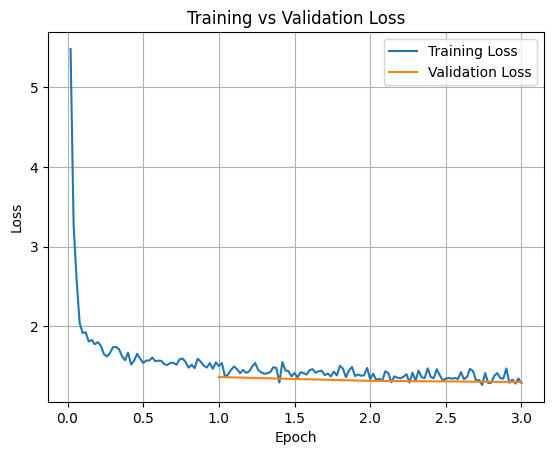

In [ ]:

df = pd.DataFrame(trainer.state.log_history)

train_df = df[df["loss"].notnull() & df["epoch"].notnull()]
eval_df = df[df["eval_loss"].notnull() & df["epoch"].notnull()]

plt.plot(train_df["epoch"], train_df["loss"], label="Training Loss")
plt.plot(eval_df["epoch"], eval_df["eval_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


During evaluation, one of the main challenges I encountered was handling long input documents. Many bill texts in the BillSum dataset exceed the token limit of 1024, which meant truncating important context that could impact the quality of the generated summary.

Another challenge was the variability in the quality and length of the reference summaries. Some human-written summaries were highly detailed, while others were more concise. This made it harder for the model to consistently match the target summaries and affected metric scores like ROUGE and BLEU.

Also, computing BERTScore and BLEU for large test sets in Colab required careful memory handling and some runtime restarts due to package updates.

Overall, while the model performed reasonably well, summarizing lengthy and diverse legal texts with a fixed-length transformer model introduced some inherent limitations.

To improve summarization quality, I could experiment with long-context models like PEGASUS, which is better suited for handling longer documents without truncation. Another enhancement would be using instruction tuned models such as BART-large-cnn, which is trained with summarization-specific tasks and often produce more coherent outputs. I could also apply summary length control or coverage penalties during generation to reduce redundancy and improve informativeness.

5. References. Include details on all the resources used to complete this part, e.g. links to datasets, research papers or articles, code examples or tutorials you referred.

6. Contribution Summary (For team assignments). If you are working in a team, provide a contribution summary. We expect equal contribution for the assignment. If the contribution is highly skewed, then the scores of the team members may be scaled w.r.t the contribution.

**Team Contribution Summary Table:**

| Team Member | Step# | Contribution (%) |
|---|---|---|
|   | Step 1 |   |
|   | Step 2 |   |
|   | Step 3 |   |
|   | **Total** |   |